# Objet

Cette étude a pour but d'étudier la possibilité d'utiliser des algorithmes de vision traditionnels pour compléter ou concurrencer les algorithmes d'IA pour la détection des défauts

In [1]:
from pathlib import Path
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

from pure_vision import *

## Détection des pattern dans l'image

In [2]:
image_path = Path("../data/pcb_defect_sample/open/open_0003.png")

Line summary:
{'vertical_count': 3, 'horizontal_count': 2, 'oblique_count': 0, 'vertical_positions': [13, 29, 45], 'horizontal_positions': [19, 43], 'oblique_lines': []}


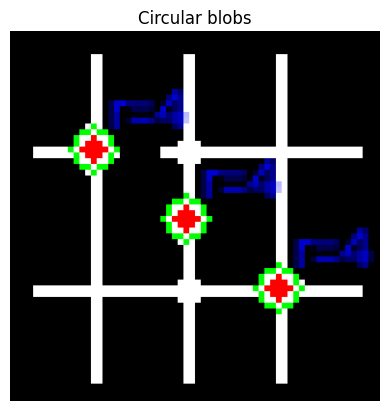


Detected circles:
{'x': 46, 'y': 44, 'r': 4, 'area': 33.5, 'circularity': 0.7908958272640014, 'fill_ratio': 0.6664613241973117} plain: True fill_ratio: 0.939
{'x': 30, 'y': 32, 'r': 4, 'area': 33.0, 'circularity': 0.8202139593974218, 'fill_ratio': 0.6565141402540683} plain: True fill_ratio: 0.878
{'x': 14, 'y': 20, 'r': 4, 'area': 35.5, 'circularity': 0.7810175211984732, 'fill_ratio': 0.7062500599702856} plain: True fill_ratio: 0.918

Detected lines:


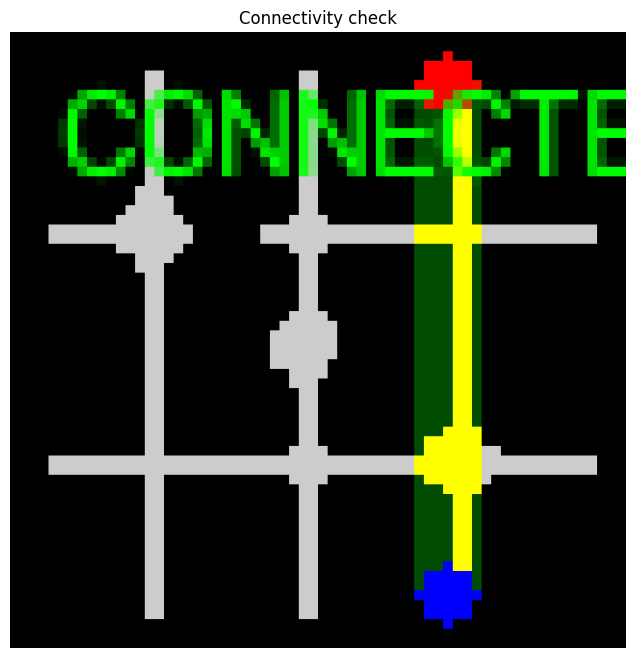

'vertical (np.int32(45), np.int32(59), np.int32(45), np.int32(5)) angle: 90.0 plain: True length: 53'

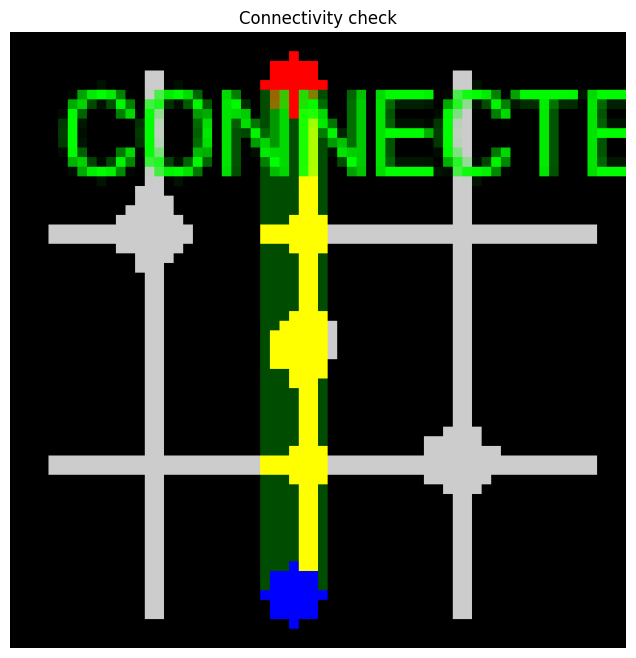

'vertical (np.int32(29), np.int32(29), np.int32(29), np.int32(5)) angle: 90.0 plain: True length: 53'

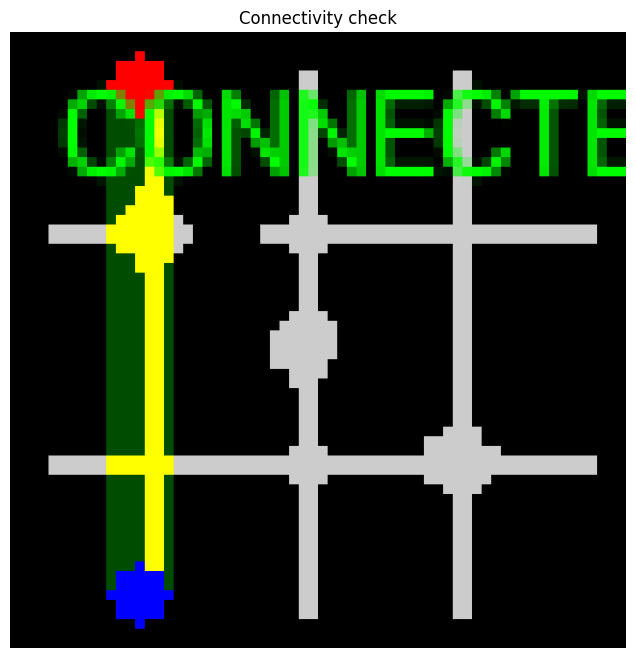

'vertical (np.int32(13), np.int32(59), np.int32(13), np.int32(24)) angle: 90.0 plain: True length: 53'

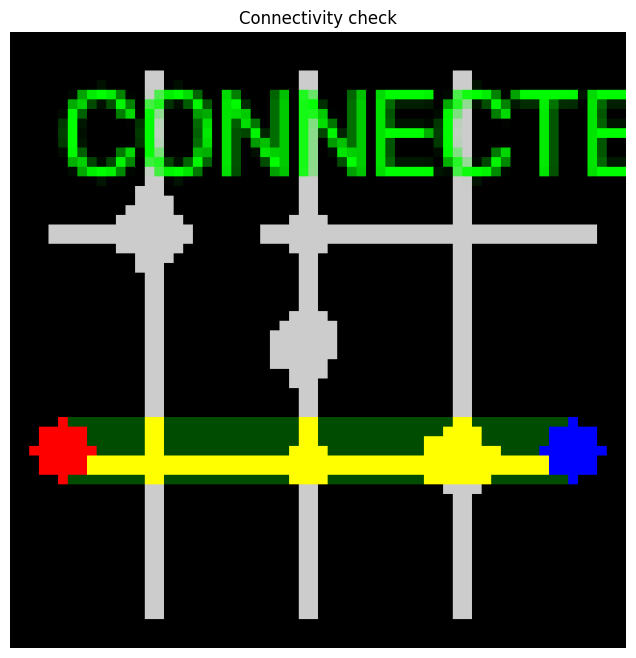

'horizontal (np.int32(5), np.int32(43), np.int32(42), np.int32(43)) angle: 0.0 plain: True length: 53'

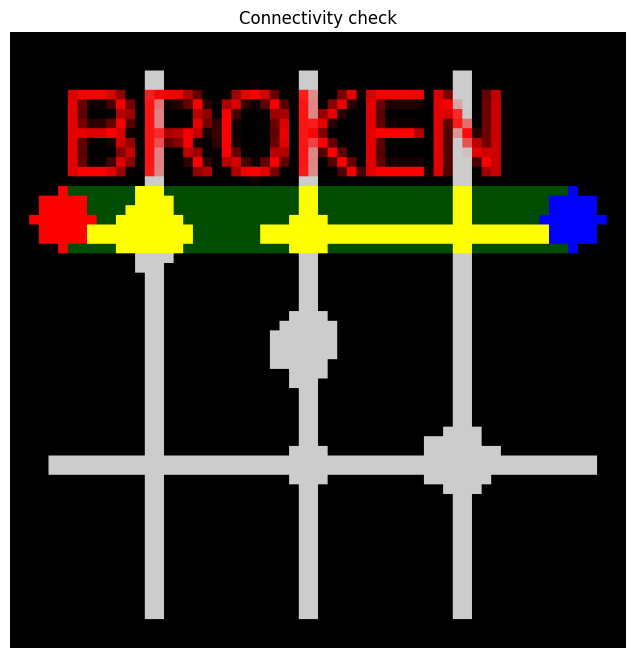

'horizontal (np.int32(27), np.int32(19), np.int32(59), np.int32(19)) angle: 0.0 plain: False length: 53'

In [3]:

# On seuille pour avoir du blanc sur noir
gray, binary = load_binary_image(image_path)

# on détecte les lignes 
lines = detect_lines(binary)
line_summary = count_lines(lines)

print("Line summary:")
print(line_summary)

# On détecte les cercles présents dans l'image
circles = detect_circular_blobs(binary, show=True)

# Les cerlces sont-ils pleins
print("\nDetected circles:")
plainCircles = 0
for circle in circles:
    plain, ratio = is_plain_circle(binary, circle)
    print(circle, "plain:", plain, "fill_ratio:", round(ratio, 3))

# Les lignes sont elles pleines
print("\nDetected lines:")
plainLines = 0
vertical_lengths = []
horizontal_lengths = []
for line in lines:
    plain, info = is_plain_line(binary, line, 0.75, True)
    display(
        f"{line['orientation']} "
        f"{line['points']} "
        f"angle: {line['angle']:.1f} "
        f"plain: {plain} "
        f"length: {info['length']}"
    )


In [4]:
rows = []
image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

In [5]:
root_dir = Path("../data/test")

In [6]:
import time

for class_dir in sorted(root_dir.iterdir()):
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name

    image_paths = sorted(
        p for p in class_dir.rglob("*")
        if p.suffix.lower() in image_extensions
    )

    print(f"Classe {class_name} : {len(image_paths)} images")

    for image_path in image_paths:
        try:
            print(f"Image : {image_path.name}")

            start = time.perf_counter()

            # On seuille pour avoir du blanc sur noir
            gray, binary = load_binary_image(image_path)

            # on détecte les lignes 
            lines = detect_lines(binary, show=False)
            line_summary = count_lines(lines)

            # print("Line summary:")
            # print(line_summary)

            # On détecte les cercles présents dans l'image
            circles = detect_circular_blobs(binary, show=False)

            # Détection des erreurs
            # =====================
            circuitOk = True

            # Les cerlces sont-ils pleins
            # print("\nDetected circles:")
            plainCircles = 0
            for circle in circles:
                plain, ratio = is_plain_circle(binary, circle)
                # print(circle, "plain:", plain, "fill_ratio:", round(ratio, 3))
                if plain == False:
                    circuitOk = False
                else:
                    plainCircles += 1
            
            # A t on bien les 3 cercles
            if len(circles) != 3:
                circuitOk = False

            # Les lignes sont elles pleines
            # print("\nDetected lines:")
            plainLines = 0
            vertical_lengths = []
            horizontal_lengths = []
            for line in lines:
                plain, info = is_plain_line(binary, line, 0.75,False)
                # print(
                #     line["orientation"],
                #     line["points"],
                #     "angle:",
                #     round(line["angle"], 1),
                #     "plain:",
                #     plain,
                # )
                if plain == False:
                    circuitOk = False
                    break
                else:
                    plainLines += 1
                
                if line["orientation"] == "vertical":
                    vertical_lengths.append(info["length"])
                elif line["orientation"] == "horizontal":
                    horizontal_lengths.append(info["length"])

            # A t on bien 3 lignes verticales et 2 lignes horizontales
            nb_vertical = sum(
                1 for line in lines
                if line["orientation"] == "vertical"
            )

            nb_horizontal = sum(
                1 for line in lines
                if line["orientation"] == "horizontal"
            )

            if nb_vertical != 3 or nb_horizontal != 2:
                circuitOk = False

            # Les lignes sont elles de la même longueur
            if not same_lengths(vertical_lengths) or not same_lengths(horizontal_lengths):
                circuitOk = False 

            # Y a t il une ligne oblique
            oblique_lines = [
                line
                for line in lines
                if line["orientation"] == "oblique"
            ]
            if len(oblique_lines) > 0:
                circuitOk = False 

            elapsed = time.perf_counter() - start
            display(f"Temps de traitement : {elapsed:.4f} s")

            rows.append({
                "class": class_name,
                "image_path": str(image_path),
                "image_name": image_path.name,
                "total_lines": len(lines),
                "complete_lines": plainLines,
                "total_circles": len(circles),
                "complete_circles": plainCircles,
                "circuit_complete": circuitOk
            })

            display(f"Circuit OK : {circuitOk}")

        except Exception as e:
            rows.append({
                "class": class_name,
                "image_path": str(image_path),
                "image_name": image_path.name,
                "total_lines": np.nan,
                "complete_lines": np.nan,
                "line_complete_rate": np.nan,
                "circuit_complete": False,
                "error": str(e)
            })

df = pd.DataFrame(rows)

# Dossier parent de chaque image
df["path"] = df["image_path"].apply(lambda p: str(Path(p).parent))

# Statut OK / KO
df["status"] = df["circuit_complete"].map({
    True: "OK",
    False: "KO"
})

summary = (
    df
    .groupby(["path", "status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Sécurité si une colonne manque
if "OK" not in summary.columns:
    summary["OK"] = 0

if "KO" not in summary.columns:
    summary["KO"] = 0

summary["total"] = summary["OK"] + summary["KO"]
summary["ok_rate"] = summary["OK"] / summary["total"]
summary["ko_rate"] = summary["KO"] / summary["total"]

print(summary)

Classe copper : 4 images
Image : copper_0000.png


'Temps de traitement : 0.0019 s'

'Circuit OK : False'

Image : copper_0063.png


'Temps de traitement : 0.0020 s'

...

'Circuit OK : False'

Image : spur_0111.png


'Temps de traitement : 0.0021 s'

'Circuit OK : False'

status                    path  KO  OK  total  ok_rate  ko_rate
0          ..\data\test\copper   4   0      4     0.00     1.00
1       ..\data\test\mousebite   4   0      4     0.00     1.00
2              ..\data\test\ok   0  16     16     1.00     0.00
3            ..\data\test\open   3   1      4     0.25     0.75
4        ..\data\test\pin_hole   2   2      4     0.50     0.50
5           ..\data\test\short   3   1      4     0.25     0.75
6            ..\data\test\spur   4   0      4     0.00     1.00


On réussit à détecter les lignes horizontales, verticales ainsi que les cercles

## Si on passe le jeu complet


| Classe | KO | OK | Total | Taux OK | Taux KO |
|----------|---:|---:|------:|--------:|--------:|
| copper | 267 | 33 | 300 | 11.00% | 89.00% |
| mousebite | 165 | 135 | 300 | 45.00% | 55.00% |
| ok | 0 | 300 | 300 | 100.00% | 0.00% |
| open | 258 | 42 | 300 | 14.00% | 86.00% |
| pin_hole | 250 | 50 | 300 | 16.67% | 83.33% |
| short | 231 | 69 | 300 | 23.00% | 77.00% |
| spur | 300 | 0 | 300 | 0.00% | 100.00% |


## Conclusion
- Détecter les défauts semble possible avec des algorithmes de vision traditionnel
- Le nombre de traitement pour chaque règle peut devenir rédibitoire
- le temps de traitement est très rapide ~0.002 s
- Sur les tests faits on remarque que le fichier /data/pcb_defect_sample/open/open_0020.png n'est pas reconnu comme KO : il semble correct lorsqu'on lme visualise
- On pourrait utiliser cet algorithme pour vérifier la qualité du dataset

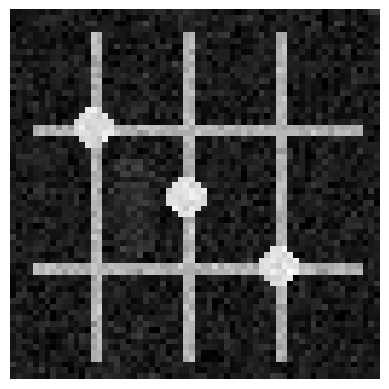

In [7]:
image_path = Path("../data/pcb_defect_sample/open/open_0020.png")

img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()